# Universidad Autónoma de Aguascalientes

# Departamento: Ciencias de la Computación

# Carrera: Ingeniería en Computación Inteligente

## Curso: Aprendizaje Automático

## Maestro: Dr. Francisco Javier Luna Rosas

## Alumno: Carlos Leonardo Cruz Ortiz

### Semestre: Enero-Junio del 2026

# PRÁCTICA 11. Curva ROC
### La Curva ROC gráfica la Tasa de Verdaderos Positivos (Sensibilidad) en el eje Y contra la Tasa de Falsos Positivos (1 - Especificidad) en el eje X.

### 1. Tasa de Verdaderos Positivos (TPR) o Sensibilidad: Proporción de muestras positivas correctamente clasificadas. TPR = TP / (TP + FN)

### 2. Tasa de Falsos Positivos (FPR): Proporción de muestras negativas incorrectamente que fueron clasificadas erróneamente como positivas. FPR = FP / (FP + TN)

## Paso 1: Importar librerías necesarias

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

## Paso 2: Generar dataset sintético
### Creamos un dataset aleatorio con 1000 muestras y 10 características para clasificación binaria

In [3]:
np.random.seed(42)

X = np.random.randn(1000, 10)
y = np.random.randint(0, 2, 1000)

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribución de clases:")
print(f"Clase 0: {np.sum(y == 0)} muestras ({np.sum(y == 0)/len(y)*100:.2f}%)")
print(f"Clase 1: {np.sum(y == 1)} muestras ({np.sum(y == 1)/len(y)*100:.2f}%)")

Shape de X: (1000, 10)
Shape de y: (1000,)

Distribución de clases:
Clase 0: 497 muestras (49.70%)
Clase 1: 503 muestras (50.30%)


## Paso 3: División de datos y normalización

In [12]:
# Dividir en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=42, stratify=y)

print(f"Tamaño de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño de prueba: {X_test.shape[0]}")

# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos normalizados correctamente")

Tamaño de entrenamiento: 700
Tamaño de prueba: 300

Datos normalizados correctamente


## Paso 4: Entrenar dos modelos de clasificación

In [ ]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Obtener probabilidades predichas
y_pred_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

y_pred_lr = model_lr.predict(X_test_scaled)

MODELO 1: REGRESIÓN LOGÍSTICA
Accuracy: 49.67%



In [13]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Obtener probabilidades predichas
y_pred_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = model_rf.predict(X_test_scaled)

## Paso 5: Calcular Curva ROC y AUC-ROC

In [19]:
# Calcular curva ROC para Regresión Logística
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

print("=" * 50)
print(" " * 14 + "REGRESIÓN LOGÍSTICA")
print("=" * 50)
print(f"AUC-ROC: {auc_lr:.4f}")
print(f"Número de umbrales evaluados: {len(thresholds_lr)}")

# Calcular curva ROC para Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

print("\n" + "=" * 50)
print(" " * 17 + "RANDOM FOREST")
print("=" * 50)
print(f"AUC-ROC: {auc_rf:.4f}")
print(f"Número de umbrales evaluados: {len(thresholds_rf)}")

              REGRESIÓN LOGÍSTICA
AUC-ROC: 0.5036
Número de umbrales evaluados: 161

                 RANDOM FOREST
AUC-ROC: 0.5129
Número de umbrales evaluados: 42


## Paso 6: Visualizar las Curvas ROC

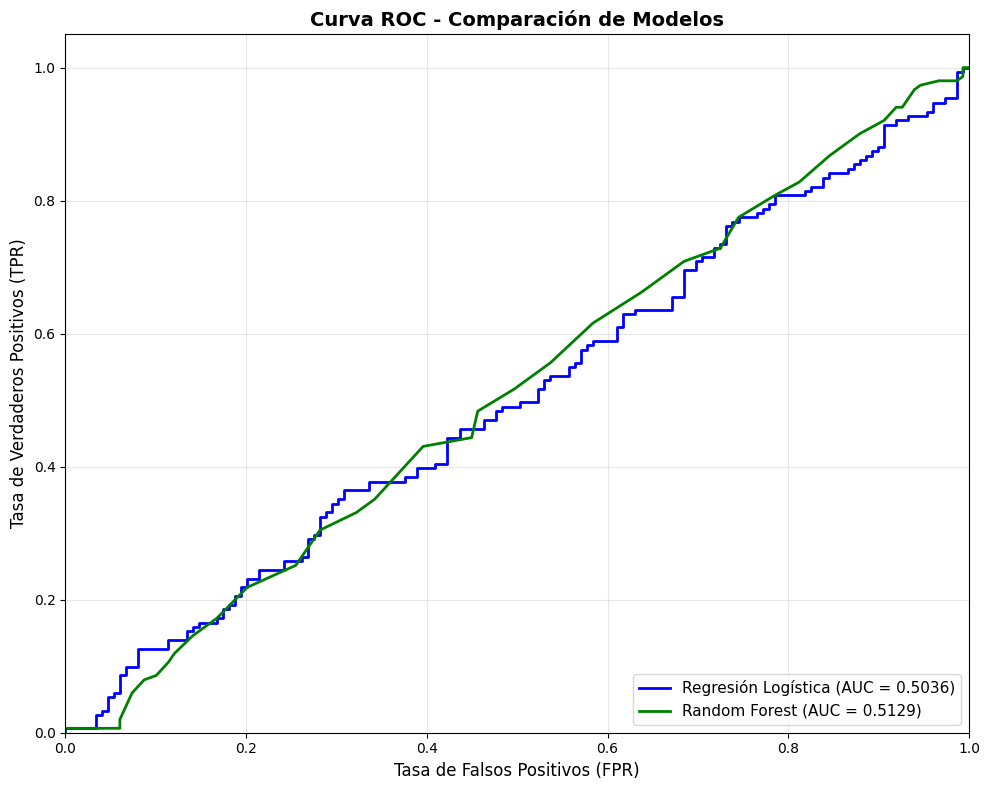

In [21]:
# Crear figura
plt.figure(figsize=(10, 8))

# Plotear curva ROC para Regresión Logística
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2,
         label=f'Regresión Logística (AUC = {auc_lr:.4f})')

# Plotear curva ROC para Random Forest
plt.plot(fpr_rf, tpr_rf, color='green', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.4f})')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curva ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 7: Comparación detallada de modelos

In [9]:
# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'AUC-ROC': [auc_lr, auc_rf]
})

print("="*60)
print("COMPARACIÓN ENTRE MODELOS")
print("="*60)
print(comparacion.to_string(index=False))

# Identificar mejor modelo según AUC-ROC
mejor_modelo = comparacion.loc[comparacion['AUC-ROC'].idxmax(), 'Modelo']
mejor_auc = comparacion['AUC-ROC'].max()
print(f"\nMejor modelo según AUC-ROC: {mejor_modelo} con AUC = {mejor_auc:.4f}")

COMPARACIÓN ENTRE MODELOS
             Modelo  Accuracy  AUC-ROC
Regresión Logística  0.496667 0.503578
      Random Forest  0.513333 0.512889

Mejor modelo según AUC-ROC: Random Forest con AUC = 0.5129


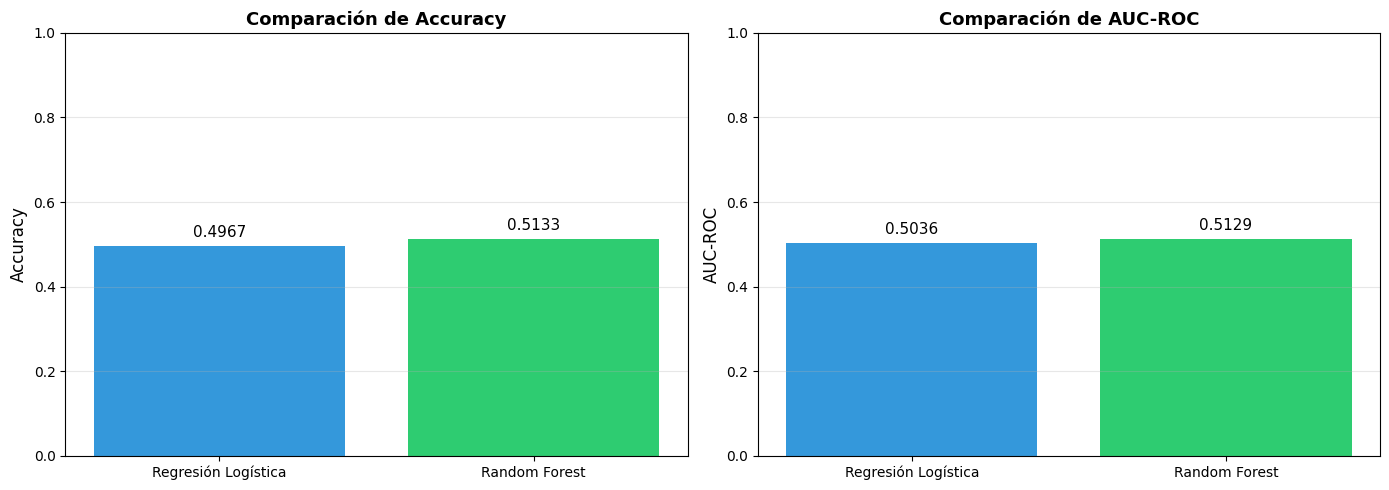

In [10]:
# Gráfico de barras comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Accuracy
ax1.bar(comparacion['Modelo'], comparacion['Accuracy'], color=['#3498db', '#2ecc71'])
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Comparación de Accuracy', fontsize=13, fontweight='bold')
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(comparacion['Accuracy']):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11)

# Gráfico 2: AUC-ROC
ax2.bar(comparacion['Modelo'], comparacion['AUC-ROC'], color=['#3498db', '#2ecc71'])
ax2.set_ylabel('AUC-ROC', fontsize=12)
ax2.set_title('Comparación de AUC-ROC', fontsize=13, fontweight='bold')
ax2.set_ylim([0, 1.0])
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(comparacion['AUC-ROC']):
    ax2.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## Paso 8: Interpretación de métricas en diferentes umbrales

In [11]:
# Analizar algunos umbrales específicos para el mejor modelo
if auc_lr > auc_rf:
    mejor_fpr, mejor_tpr, mejor_thresholds = fpr_lr, tpr_lr, thresholds_lr
    mejor_nombre = 'Regresión Logística'
else:
    mejor_fpr, mejor_tpr, mejor_thresholds = fpr_rf, tpr_rf, thresholds_rf
    mejor_nombre = 'Random Forest'

# Seleccionar algunos umbrales de interés
indices = [0, len(mejor_thresholds)//4, len(mejor_thresholds)//2, 
           3*len(mejor_thresholds)//4, len(mejor_thresholds)-1]

print("="*70)
print(f"ANÁLISIS DE UMBRALES - {mejor_nombre}")
print("="*70)
print(f"{'Umbral':<15} {'TPR (Sensibilidad)':<20} {'FPR (1-Especificidad)'}")
print("="*70)

for idx in indices:
    if idx < len(mejor_thresholds):
        print(f"{mejor_thresholds[idx]:<15.4f} {mejor_tpr[idx]:<20.4f} {mejor_fpr[idx]:.4f}")

print("\nInterpretación:")
print("- TPR alto = El modelo detecta más casos positivos (mayor sensibilidad)")
print("- FPR bajo = El modelo genera menos falsos positivos (mayor especificidad)")
print("- El umbral óptimo depende del costo relativo de FP vs FN en la aplicación")

ANÁLISIS DE UMBRALES - Random Forest
Umbral          TPR (Sensibilidad)   FPR (1-Especificidad)
inf             0.0000               0.0000
0.6200          0.1192               0.1208
0.5000          0.5166               0.4966
0.4000          0.9007               0.8792
0.2800          1.0000               1.0000

Interpretación:
- TPR alto = El modelo detecta más casos positivos (mayor sensibilidad)
- FPR bajo = El modelo genera menos falsos positivos (mayor especificidad)
- El umbral óptimo depende del costo relativo de FP vs FN en la aplicación


# Conclusiones

### La Curva ROC gráfica la Tasa de Verdaderos Positivos (Sensibilidad) en el eje Y contra la Tasa de Falsos Positivos (1 - Especificidad) en el eje X, para diferentes umbrales de clasificación.

### En esta practica implementamos 2 modelos para implementar la curva ROC y el Área bajo la Curva ROC (AUC-ROC).

# Referencias

### [1] John chambers. (2008). Software for Data Analysis programming with R. USA : Springer Verlag 2008.

### [2] Reporte Técnico de PROMIDAT: http://promidat.com/ (Ultimo acceso febrero 2025)